# **Imports**

In [3]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO


# Uploaded

In [4]:
data = """id_transacao,id_cliente,valor,data_hora,categoria,localizacao,canal,fraude
1,1001,45.50,2026-04-18 10:20,restaurante,Sao Paulo,cartao_fisico,0
2,1002,1200.00,2026-04-18 10:25,eletronicos,Rio de Janeiro,online,0
3,1003,15.00,2026-04-18 11:00,transporte,Recife,cartao_fisico,0
4,1001,8900.00,2026-04-18 03:15,joalheria,Londres,online,1
5,1004,55.20,2026-04-18 12:30,supermercado,Curitiba,cartao_fisico,0
6,1005,10.00,2026-04-18 14:00,servicos,Belo Horizonte,app,0
7,1002,1300.00,2026-04-18 14:05,eletronicos,Rio de Janeiro,online,0
8,1003,22.40,2026-04-18 15:10,transporte,Recife,cartao_fisico,0
9,1006,5.00,2026-04-18 16:00,outros,Sao Paulo,online,1
10,1006,5.00,2026-04-18 16:01,outros,Sao Paulo,online,1
11,1006,4500.00,2026-04-18 16:05,eletronicos,Sao Paulo,online,1
12,1007,320.00,2026-04-18 17:00,vestuario,Porto Alegre,cartao_fisico,0
13,1008,120.00,2026-04-18 18:20,restaurante,Salvador,cartao_fisico,0
14,1004,60.00,2026-04-18 19:00,supermercado,Curitiba,cartao_fisico,0
15,1009,2500.00,2026-04-18 20:15,viagem,Brasilia,online,0
16,1010,12.50,2026-04-18 21:00,transporte,Manaus,app,0
17,1005,150.00,2026-04-18 22:00,lazer,Belo Horizonte,cartao_fisico,0
18,1011,75.00,2026-04-19 08:30,saude,Fortaleza,cartao_fisico,0
19,1012,3000.00,2026-04-19 02:45,eletronicos,Dubai,online,1
20,1001,35.00,2026-04-19 09:00,restaurante,Sao Paulo,cartao_fisico,0
21,1013,18.00,2026-04-19 10:15,transporte,Natal,app,0
22,1007,450.00,2026-04-19 11:30,vestuario,Porto Alegre,cartao_fisico,0
23,1014,95.00,2026-04-19 12:45,supermercado,Goiania,cartao_fisico,0
24,1015,12000.00,2026-04-19 13:00,outros,Sao Paulo,online,1
25,1002,15.50,2026-04-19 14:20,lazer,Rio de Janeiro,cartao_fisico,0
26,1016,220.00,2026-04-19 15:30,saude,Vitoria,cartao_fisico,0
27,1008,85.00,2026-04-19 16:45,restaurante,Salvador,cartao_fisico,0
28,1017,12.00,2026-04-19 17:10,transporte,Cuiaba,app,0
29,1018,540.00,2026-04-19 18:00,vestuario,Belem,online,0
30,1019,25.00,2026-04-19 19:15,lazer,Florianopolis,cartao_fisico,0
31,1020,110.00,2026-04-19 20:30,supermercado,Aracaju,cartao_fisico,0
32,1011,9.90,2026-04-19 21:45,servicos,Fortaleza,app,0
33,1013,10500.00,2026-04-20 01:10,eletronicos,Miami,online,1
34,1013,50.00,2026-04-20 09:30,transporte,Natal,app,0
35,1021,210.00,2026-04-20 10:00,saude,Joao Pessoa,cartao_fisico,0
36,1022,45.00,2026-04-20 10:45,restaurante,Maceio,cartao_fisico,0
37,1004,78.00,2026-04-20 11:30,supermercado,Curitiba,cartao_fisico,0
38,1023,300.00,2026-04-20 12:15,vestuario,Teresina,online,0
39,1024,15.00,2026-04-20 13:00,transporte,Campo Grande,app,0
40,1025,980.00,2026-04-20 14:10,viagem,Sao Luis,online,0
41,1026,2.00,2026-04-20 14:30,outros,Belo Horizonte,online,1
42,1026,1.50,2026-04-20 14:31,outros,Belo Horizonte,online,1
43,1026,3500.00,2026-04-20 14:35,eletronicos,Belo Horizonte,online,1
44,1027,65.00,2026-04-20 15:20,lazer,Palmas,cartao_fisico,0
45,1028,125.00,2026-04-20 16:40,saude,Rio Branco,cartao_fisico,0
46,1029,40.00,2026-04-20 17:15,restaurante,Boa Vista,cartao_fisico,0
47,1030,22.00,2026-04-20 18:00,transporte,Macapa,app,0
48,1012,140.00,2026-04-20 19:30,vestuario,Porto Velho,cartao_fisico,0
49,1015,11.00,2026-04-20 20:10,servicos,Sao Paulo,app,0
50,1017,89.00,2026-04-20 21:00,supermercado,Cuiaba,cartao_fisico,0
51,1009,2100.00,2026-04-20 22:15,viagem,Brasilia,online,0
52,1018,45.00,2026-04-20 23:00,lazer,Belem,cartao_fisico,0
53,1031,7500.00,2026-04-21 04:20,joalheria,Paris,online,1
54,1032,32.00,2026-04-21 08:00,transporte,Recife,app,0
55,1033,150.00,2026-04-21 09:15,saude,Sao Paulo,cartao_fisico,0
56,1034,220.00,2026-04-21 10:30,vestuario,Curitiba,online,0
57,1035,55.00,2026-04-21 11:45,restaurante,Rio de Janeiro,cartao_fisico,0
58,1036,12.00,2026-04-21 12:30,transporte,Belo Horizonte,app,0
59,1037,95.00,2026-04-21 13:15,supermercado,Porto Alegre,cartao_fisico,0
60,1038,3400.00,2026-04-21 02:00,eletronicos,Hong Kong,online,1
"""

df = pd.read_csv(StringIO(data))

In [5]:
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['data'] = df['data_hora'].dt.hour
df['dia'] = df['data_hora'].dt.date

In [6]:
df['fraude'].value_counts(normalize=True)
df.groupby('fraude')['valor'].mean()
pd.crosstab(df['canal'], df['fraude'], normalize='index')

fraude,0,1
canal,,
app,1.0,0.0
cartao_fisico,1.0,0.0
online,0.4,0.6


In [7]:
df.groupby('fraude')['valor'].describe()

,count,mean,std,min,25%,50%,75%,max
fraude,,,,,,,,
0,48.0,257.916667,517.073932,9.9,24.35,70.0,165.0,2500.0
1,12.0,4442.791667,4326.548937,1.5,5.00,3450.0,7850.0,12000.0


In [8]:
df['transacoes_cliente'] = df.groupby('id_cliente')['id_transacao'].transform('count')

In [9]:
df.head()

,id_transacao,id_cliente,valor,data_hora,categoria,localizacao,canal,fraude,data,dia,transacoes_cliente
0,1,1001,45.5,2026-04-18 10:20:00,restaurante,Sao Paulo,cartao_fisico,0,10,2026-04-18,3
1,2,1002,1200.0,2026-04-18 10:25:00,eletronicos,Rio de Janeiro,online,0,10,2026-04-18,3
2,3,1003,15.0,2026-04-18 11:00:00,transporte,Recife,cartao_fisico,0,11,2026-04-18,2
3,4,1001,8900.0,2026-04-18 03:15:00,joalheria,Londres,online,1,3,2026-04-18,3
4,5,1004,55.2,2026-04-18 12:30:00,supermercado,Curitiba,cartao_fisico,0,12,2026-04-18,3


In [12]:
df[df['fraude'] == 1]['localizacao'].value_counts()

,count
localizacao,
Sao Paulo,4
Belo Horizonte,3
Londres,1
Dubai,1
Miami,1
Paris,1
Hong Kong,1


In [14]:
df.groupby('fraude')['valor'].mean()

,valor
fraude,
0,257.916667
1,4442.791667


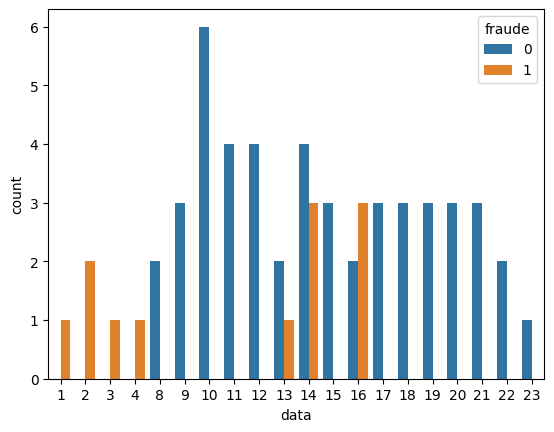

In [10]:
sns.countplot(x='data', hue='fraude', data=df)
plt.show()

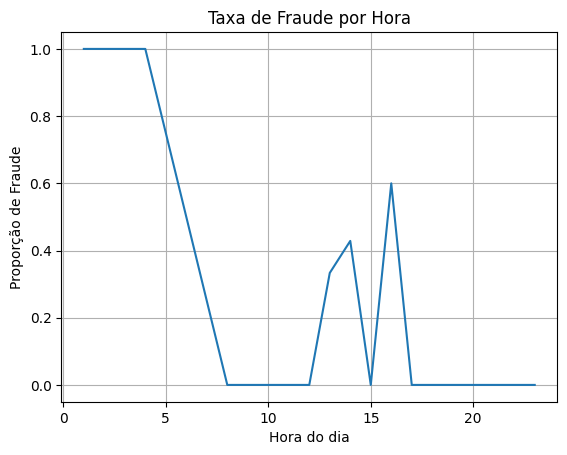

In [29]:
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['hora'] = df['data_hora'].dt.hour

fraude_por_hora = df.groupby('hora')['fraude'].mean()

plt.figure()
plt.plot(fraude_por_hora.index, fraude_por_hora.values)
plt.title("Taxa de Fraude por Hora")
plt.xlabel("Hora do dia")
plt.ylabel("Proporção de Fraude")
plt.grid()
plt.show()

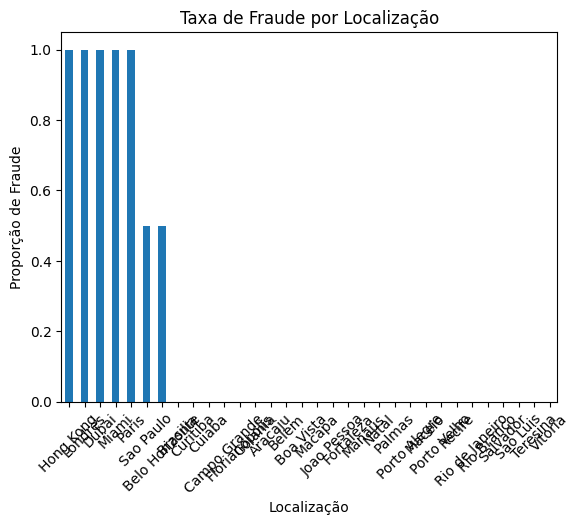

In [30]:
fraude_local = df.groupby('localizacao')['fraude'].mean().sort_values(ascending=False)

plt.figure()
fraude_local.plot(kind='bar')
plt.title("Taxa de Fraude por Localização")
plt.xlabel("Localização")
plt.ylabel("Proporção de Fraude")
plt.xticks(rotation=45)
plt.show()

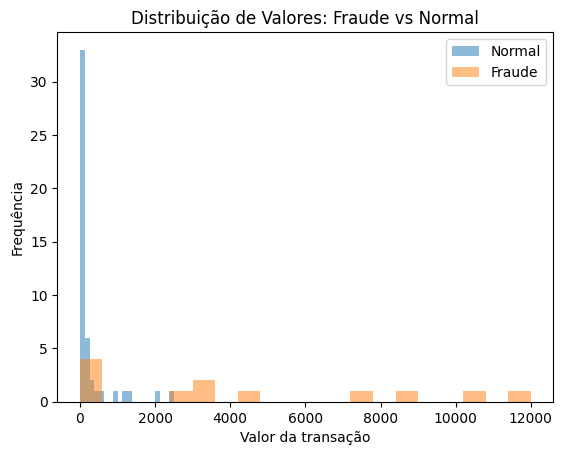

In [31]:
plt.figure()
df[df['fraude'] == 0]['valor'].plot(kind='hist', bins=20, alpha=0.5)
df[df['fraude'] == 1]['valor'].plot(kind='hist', bins=20, alpha=0.5)

plt.title("Distribuição de Valores: Fraude vs Normal")
plt.xlabel("Valor da transação")
plt.ylabel("Frequência")
plt.legend(["Normal", "Fraude"])
plt.show()

Testes

In [15]:
!pip install pytest

In [26]:
with open("fraude.py", "w") as f:
    f.write("""
def detectar_fraude_regra(row):
    if row['valor'] > 5000:
        return 1
    if row['hora'] < 5:
        return 1
    if row['localizacao'] in ['Dubai', 'Londres', 'Paris', 'Hong Kong']:
        return 1
    return 0
""")

In [25]:
with open("test_fraude.py", "w") as f:
    f.write("""
from fraude import detectar_fraude_regra

def test_valor_alto():
    row = {'valor': 6000, 'hora': 14, 'localizacao': 'Sao Paulo'}
    assert detectar_fraude_regra(row) == 1

def test_madrugada():
    row = {'valor': 100, 'hora': 2, 'localizacao': 'Recife'}
    assert detectar_fraude_regra(row) == 1

def test_normal():
    row = {'valor': 100, 'hora': 14, 'localizacao': 'Recife'}
    assert detectar_fraude_regra(row) == 0
""")

In [27]:
!ls

fraude.py  sample_data	test_fraude.py


In [28]:
!pytest -v

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.13.0, langsmith-0.7.30, typeguard-4.5.1
collected 3 items                                                              

test_fraude.py::test_valor_alto PASSED                                   [ 33%]
test_fraude.py::test_madrugada PASSED                                    [ 66%]
test_fraude.py::test_normal PASSED                                       [100%]

============================== 3 passed in 0.03s ===============================
